# Neutral atom hardware quickstart

这个 notebook 是“真实硬件接入前的最小闭环”教程。它可以 offline 完整执行：所有会打开 qCMOS 或连接远程 FPGA 的动作都只写成说明或配置检查；真正采图和画图用 virtual device 走同一套 `frontend` / `neutral_atom` 接口。

目标线路是：

```text
control PC / Jupyter
  -> device config
  -> camera.capture()
  -> readout.sitemap()
  -> readout.thresholds()
  -> readout.detect()
  -> readout.detection_time()
  -> later switch camera/sequencer config to real hardware
```

In [1]:
from pathlib import Path
import os
import sys

def _find_project_root():
    for root in (Path.cwd(), *Path.cwd().parents):
        if (root / "pyproject.toml").is_file() and (root / "Zou_lab_control").is_dir():
            return root.resolve()
    raise ModuleNotFoundError("Cannot find the Zou_lab_control project root from this notebook cwd.")

PROJECT_ROOT = _find_project_root()
project_root_str = str(PROJECT_ROOT)
sys.path = [p for p in sys.path if p != project_root_str]
sys.path.insert(0, project_root_str)

pythonpath = [p for p in os.environ.get("PYTHONPATH", "").split(os.pathsep) if p and p != project_root_str]
os.environ["PYTHONPATH"] = os.pathsep.join([project_root_str, *pythonpath])

import Zou_lab_control.frontend as zf

zf.notebook_setup()

In [2]:
from pathlib import Path
import json
import numpy as np

import Zou_lab_control.frontend as zf
import Zou_lab_control.neutral_atom as na

try:
    zf.use_widget_backend()
except Exception as exc:
    print(f"Widget backend not enabled here: {exc}")

zf.enable_long_output()
zf.apply_style()

## 1. Check the public API

这一步防止 notebook 载入旧 kernel 里的旧接口。第一格已经把仓库根目录放到 `sys.path` 最前面；如果你改了源码，重启 kernel 后会优先使用当前仓库。

In [3]:
zf.require_attrs(zf, ["plot", "run", "write_neutral_atom_hardware_tutorial"], name="Zou_lab_control.frontend")
zf.require_attrs(na, ["connect", "CameraDevice", "SequencerDevice", "RuntimeSequencer", "RemoteSequencer"], name="Zou_lab_control.neutral_atom")
na.available_device_configs()

['real_manual_template', 'real_remote_template', 'real_template', 'virtual']

## 2. Inspect real-hardware configs without opening hardware

`real_manual_template` 用于 first-light：camera arm 之后由你手动或外部逻辑启动 FPGA trigger。`real_remote_template` 用于最终双 PC 架构：控制 PC 通过 `RemoteSequencer` 向 Vivado/FPGA PC 上的 sequencer service 上传 pulse table 并 fire。

下面只是构造 device object 和查看 snapshot，不会打开 qCMOS，也不会连接 RPyC。

In [4]:
for name in ["real_manual_template", "real_remote_template"]:
    devices = na.load_devices(name)
    print(f"\n{name}")
    print(json.dumps(devices.snapshot(), indent=2, default=str))
    devices.close()


real_manual_template
{
  "camera": {
    "type": "QCMOSCamera",
    "exposure": 0.02,
    "readout_speed": 1,
    "roi": [
      1648,
      64,
      1144,
      64
    ],
    "device_index": 0,
    "timeout_ms": 10000,
    "open": false
  },
  "sequencer": {
    "type": "ManualSequencer",
    "channels": [
      "trap",
      "probe",
      "qcm_trigger"
    ],
    "clock_hz": 250000000.0,
    "trigger_channels": [
      "qcm_trigger"
    ],
    "state": "idle",
    "prepared": false,
    "history_length": 0
  }
}

real_remote_template
{
  "camera": {
    "type": "QCMOSCamera",
    "exposure": 0.02,
    "readout_speed": 1,
    "roi": [
      1648,
      64,
      1144,
      64
    ],
    "device_index": 0,
    "timeout_ms": 10000,
    "open": false
  },
  "sequencer": {
    "type": "RemoteSequencer",
    "host": "192.168.0.20",
    "port": 18861,
    "channels": [
      "trap",
      "probe",
      "qcm_trigger"
    ],
    "clock_hz": 250000000.0,
    "trigger_channels": [
      "q

## 3. Use the same session shape with virtual hardware

真实和 virtual 的差别应该只在 config/device 层。readout、timing、frontend、result object 都不需要换调用方式。

virtual camera 的噪声量级按 C15550-22UP 的读出模型近似：offset 约 200 counts，conversion 约 0.107 electrons/count，read noise 约 0.43 electrons RMS。这里不把 simulator 的 ground truth 暴露给 calibration；sitemap 和 threshold 必须从图像本身得到。

In [5]:
exp = na.connect(
    "virtual",
    bright_count_rate=3000,
    background_count_rate=8,
    loss_rate=0.1,
    exposure=2e-3,
    sitemap={"grid_shape": (5, 7), "spacing_px": 12.0, "roi_radius": 1, "sitemap_exposure": 0.02},
)
zf.require_attrs(exp, ["camera", "readout", "timing"], name="exp")
exp

name,neutral_atom
devices,"camera, sequencer, trap_array"
sequence,imaging
calibration,none
history,0


## 4. Configure and plot the pulse sequence

`PulseSequence` 是唯一的时序源。`exp.timing.configure_imaging(...)` 只生成物理时间 pulse；`exp.timing.preflight()` 检查 channel、clock tick 和 Verilog 生成；`frontend.plot(..., kind="pulse")` 负责把它画成 notebook 里的 pulse diagram。

多帧相机采集的关键规则：请求 `frames=N` 时，sequencer 必须提供 N 个 camera trigger。现在这个规则在 camera acquisition 边界统一处理：单 trigger imaging 模板会被 `sequence_for_frame_count(seq, N)` repeat；如果本来就有 N 个 trigger 就原样使用；其他不匹配会在 camera arm 前报错。

single-shot triggers: 1
five-frame triggers: 5


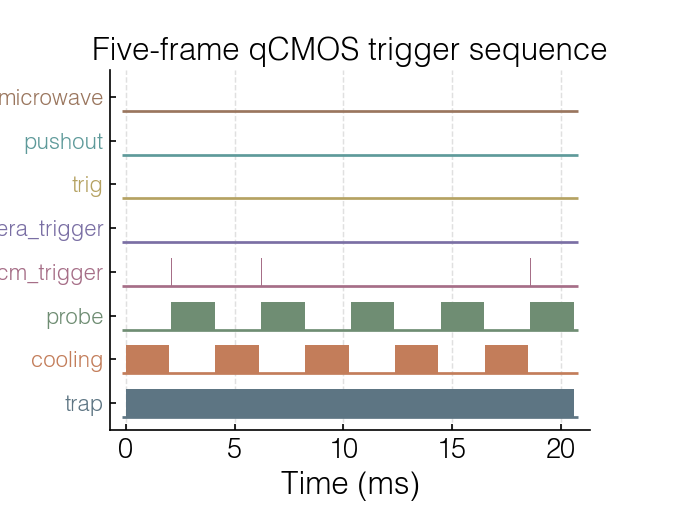

{'ok': True,
 'errors': [],
 'warnings': [],
 'sequence': [{'channel': 'cooling',
   'start': 0.0,
   'duration': 0.002,
   'value': 1,
   'name': 'load'},
  {'channel': 'trap',
   'start': 0.0,
   'duration': 0.0041199999999999995,
   'value': 1,
   'name': 'trap_hold'},
  {'channel': 'probe',
   'start': 0.0021,
   'duration': 0.002,
   'value': 1,
   'name': 'probe'},
  {'channel': 'qcm_trigger',
   'start': 0.0021,
   'duration': 2e-05,
   'value': 1,
   'name': 'camera_trigger'},
  {'channel': 'cooling',
   'start': 0.0041199999999999995,
   'duration': 0.002,
   'value': 1,
   'name': 'load'},
  {'channel': 'trap',
   'start': 0.0041199999999999995,
   'duration': 0.0041199999999999995,
   'value': 1,
   'name': 'trap_hold'},
  {'channel': 'probe',
   'start': 0.00622,
   'duration': 0.002,
   'value': 1,
   'name': 'probe'},
  {'channel': 'qcm_trigger',
   'start': 0.00622,
   'duration': 2e-05,
   'value': 1,
   'name': 'camera_trigger'},
  {'channel': 'cooling',
   'start': 0.

In [6]:
seq = exp.timing.configure_imaging(exposure=2e-3, load=True, trigger_width=20e-6, pre_trigger=100e-6)
expanded = na.sequence_for_frame_count(seq, 5)

print("single-shot triggers:", na.count_trigger_pulses(seq))
print("five-frame triggers:", na.count_trigger_pulses(expanded))

pulse_plot = zf.plot(
    expanded,
    kind="pulse",
    channels=exp.devices.sequencer.channels,
    title="Five-frame qCMOS trigger sequence",
)
exp.timing.preflight(sequence=expanded).summary()

## 5. Dry-run the runtime sequencer protocol

最终硬件路径不是让 Python 精确 sleep 每个 pulse，而是：

1. control PC 编译/发送 pulse table；
2. FPGA/Vivado PC 上的 sequencer service 接收 `prepare`；
3. qCMOS arm buffer；
4. control PC 发 `fire`；
5. FPGA 时钟执行所有 tick/mask；
6. camera 读回 frame；
7. sequencer `wait_done` 只确认 finite sequence 已结束。

下面用 `RuntimeSequencer` 在本机模拟这个协议，不连接真实 RPyC。

In [7]:
runtime = na.RuntimeSequencer(channels=["trap", "cooling", "probe", "qcm_trigger"], sleep_scale=0.0)
program = runtime.prepare(expanded)
runtime.fire(expanded)
runtime.wait_done(timeout=1.0)

program.to_dict(), runtime.snapshot()

({'schema': 'Zou_lab_control.neutral_atom.RuntimeSequenceProgram',
  'version': 1,
  'sequence_id': '2da8a113f883f3ee',
  'sequence_name': 'imaging',
  'clock_hz': 250000000.0,
  'channels': ['trap', 'cooling', 'probe', 'qcm_trigger'],
  'ticks': [0,
   500000,
   525000,
   530000,
   1025000,
   1030000,
   1530000,
   1555000,
   1560000,
   2055000,
   2060000,
   2560000,
   2585000,
   2590000,
   3085000,
   3090000,
   3590000,
   3615000,
   3620000,
   4115000,
   4120000,
   4620000,
   4645000,
   4650000,
   5145000,
   5150000],
  'masks': [3,
   1,
   13,
   5,
   1,
   3,
   1,
   13,
   5,
   1,
   3,
   1,
   13,
   5,
   1,
   3,
   1,
   13,
   5,
   1,
   3,
   1,
   13,
   5,
   1,
   0],
  'duration': 0.020599999999999997,
  'trigger_count': 5},
 {'type': 'RuntimeSequencer',
  'channels': ['trap', 'cooling', 'probe', 'qcm_trigger'],
  'clock_hz': 250000000.0,
  'trigger_channels': ['qcm_trigger', 'camera_trigger', 'trig'],
  'state': 'done',
  'prepared_program':

## 6. Capture raw camera data

`capture` 是 camera device 方法，所以调用是 `exp.camera.capture()`。它只显示 raw camera frame，不显示 sitemap 圈；sitemap 圈必须来自 calibration，不允许从 simulator 或 hardware 内部偷用 site 信息。

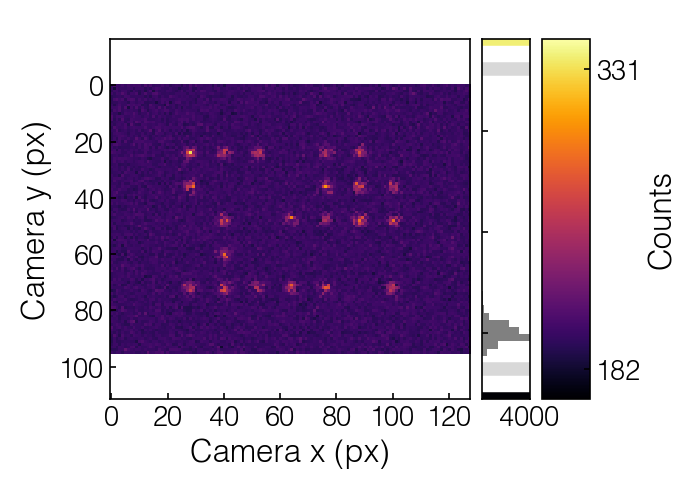

{'frames': 1, 'image_shape': [96, 128], 'sequence': 'imaging'}

In [8]:
capture = exp.camera.capture(display=True)
capture.summary()

## 7. Calibrate sitemap

`sitemap` 通过 long exposure / all-sites image stack 找 site center，并保存成 `TrapCalibration`。这一步之后，后续 threshold 和 detect 才有 camera-space site 位置可用。

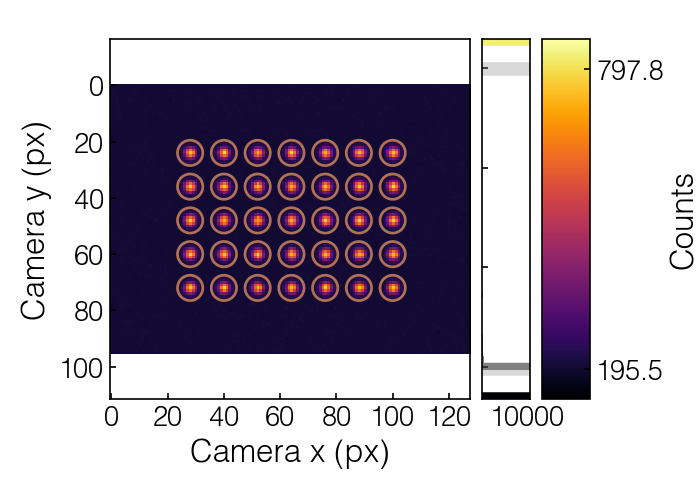

{'n_sites': 35, 'grid_shape': [5, 7], 'roi_radius': 1}

In [9]:
sitemap = exp.readout.sitemap(frames=12, display=True)
sitemap.summary()

## 8. Calibrate thresholds

`thresholds` 在 sitemap 的每个 ROI 上取 counts，给每个 site 估计 threshold。histogram 图里的 threshold 线可以拖动；图上显示当前 cut、左右比例、双峰 Gaussian 拟合 fidelity 和 fit cut。

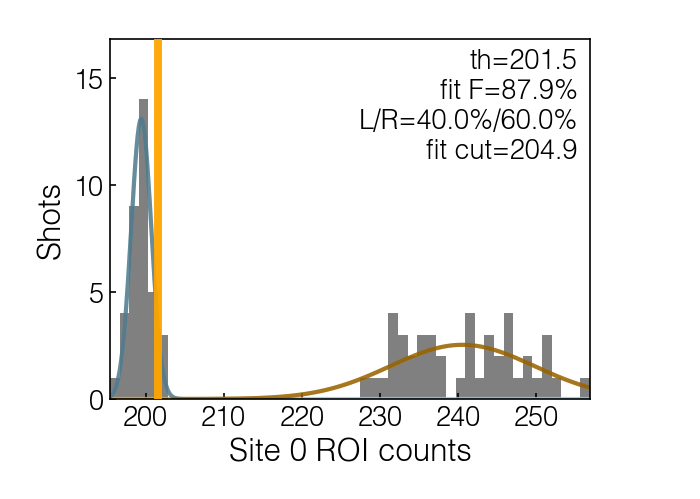

{'shots': 80,
 'sites': 35,
 'selected_site': 0,
 'selected_threshold': 201.52488425925927,
 'selected_fidelity': 0.6371414979899874}

In [10]:
threshold = exp.readout.thresholds(frames=80, site=0, display=True)
threshold.summary()

## 9. Detect occupancy

`detect` 输出 raw image + occupied array。图上所有 sitemap site 用浅色背景圈标出，只有判定为 occupied 的 site 画细橙色圈。这个 boolean array 后面可以直接交给 rearrangement 或统计逻辑。

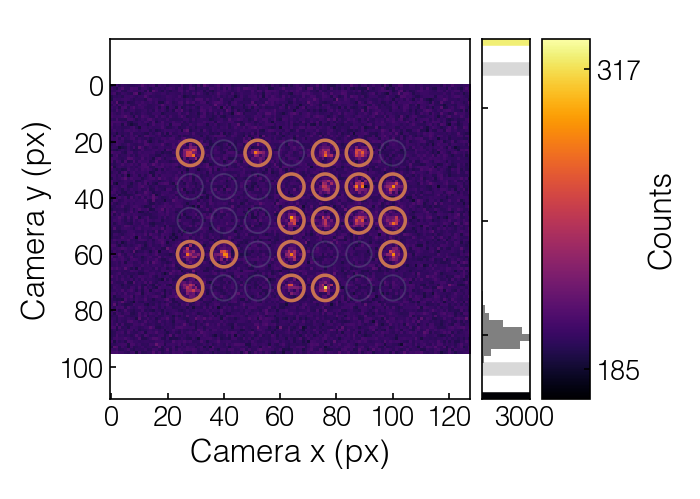

(array([[ True, False,  True, False,  True,  True, False],
        [False, False, False,  True,  True,  True,  True],
        [False, False, False,  True,  True,  True,  True],
        [ True,  True, False,  True, False, False,  True],
        [ True, False, False,  True,  True, False, False]]),
 {'loaded_atoms': 19,
  'occupied_indices': [0,
   2,
   4,
   5,
   10,
   11,
   12,
   13,
   17,
   18,
   19,
   20,
   21,
   22,
   24,
   27,
   28,
   31,
   32]})

In [11]:
shot = exp.readout.detect(display=True)
shot.occupied.reshape(exp.devices.trap_array.grid_shape), shot.summary()

## 10. Scan detection time and fidelity

这里不使用 simulator ground truth。流程先用 long-exposure reference images 建立可由真实实验得到的 count distribution，再对每个 detection time 拍 `shots` 张，估计 threshold 和 Gaussian split fidelity。

这格用 `live=False`，让数据采完后直接在同一个 `scan` 上调用 `data_figure.decay()`。正式 notebook 可以省略 `live=False`，此时返回的 `scan` 会带着 frontend live plot 和 acquisition worker，必要时调用 `scan.stop()`。

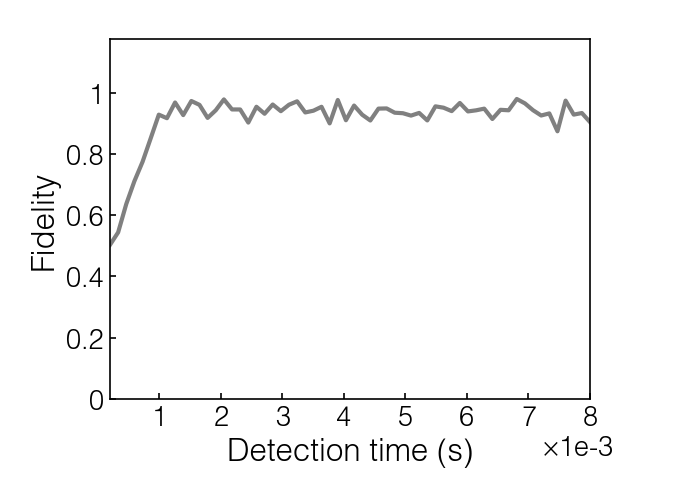

({'points': 60,
  'points_done': 60,
  'running': False,
  'finished': True,
  'best': {'time': 0.006810169491525424, 'fidelity': 0.9795895829542769}},
 FitResult(names=['A', 'B', 'tau'], popt=array([-8.03032182e-01,  9.43582545e-01,  4.14345218e-04]), pcov=array([[3.94147026e-03, 3.34239208e-05, 1.87120226e-06],
        [3.34239208e-05, 1.68557024e-05, 4.95028781e-08],
        [1.87120226e-06, 4.95028781e-08, 1.23449058e-09]]), function='decay'),
 array([-8.03032182e-01,  9.43582545e-01,  4.14345218e-04]))

In [12]:
times = np.linspace(0.2e-3, 8e-3, 60)
scan = exp.readout.detection_time(times, shots=20, live=False, display=True)
fit_result, popt = scan.data_figure.decay(is_display=False)
scan.summary(), fit_result, popt

## 11. Save calibration/status/Verilog

保存 calibration 后，真实硬件 notebook 可以先 `exp.readout.load(...)`，再跳过 sitemap 或只做快速复查。Verilog 生成仍然可用于离线 Vivado 检查；远程 runtime sequencer 使用的是同一个 `PulseSequence` 编译出的 edge table。

In [13]:
Path("results").mkdir(exist_ok=True)
Path("generated_sequences").mkdir(exist_ok=True)

calibration_path = exp.readout.save("results/hardware_quickstart_calibration.json")
status_path = exp.save_status("results/hardware_quickstart_status.json")
verilog_path = exp.timing.write_verilog("generated_sequences")

calibration_path, status_path, verilog_path

(WindowsPath('results/hardware_quickstart_calibration.json'),
 WindowsPath('results/hardware_quickstart_status.json'),
 WindowsPath('generated_sequences/neutral_atom_sequence.v'))

## 12. Where the real hardware call changes

真实运行时，前面的 notebook 结构保持不变，只把 connection cell 换成：

```python
exp = na.connect("real_remote_template")
exp.timing.configure_imaging(exposure=2e-3, load=True)
preflight = exp.timing.preflight()
preflight.raise_if_failed()
capture = exp.camera.capture(display=True)
```

如果还没有 remote sequencer service，就先用：

```python
exp = na.connect("real_manual_template")
capture = exp.camera.capture(display=True)
```

此时 `ManualSequencer.fire()` 会在 qCMOS arm 之后提示你启动 FPGA/manual trigger。这个模式只适合 first-light 和固定时序检查，不适合自动 scan。

In [14]:
real_exp = na.connect("real_remote_template")
real_exp.status()
real_exp.close()